# Setup

In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Data

In [42]:
df = pd.read_csv('listings.csv')
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20260215064701,2026-02-15,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.56,3.22,3.67,NaN,NaN,1,1,0,0,0.06
1,3820211,https://www.airbnb.com/rooms/3820211,20260215064701,2026-02-15,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.81,4.82,4.78,NaN,NaN,7,7,0,0,2.26
2,5651579,https://www.airbnb.com/rooms/5651579,20260215064701,2026-02-15,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",NaN,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.86,4.76,4.63,NaN,NaN,2,1,1,0,2.96
3,6015313,https://www.airbnb.com/rooms/6015313,20260215064701,2026-02-15,city scrape,Comfortable 3BR Home w/ Central Air | Pine Hills,Updated 3-bedroom home in Pine Hills near hosp...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,31223807,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
4,6623339,https://www.airbnb.com/rooms/6623339,20260215064701,2026-02-15,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.70,4.80,4.72,NaN,NaN,7,7,0,0,2.55


# Initial Data Inspection

In [43]:
df.shape

(453, 85)

# Handle Missing Values - Initial Scan

In [44]:
missing=df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

,0
neighborhood_overview,453
neighbourhood_group_cleansed,453
host_since,453
host_response_rate,453
host_response_time,453
host_acceptance_rate,453
host_thumbnail_url,453
host_total_listings_count,453
host_neighbourhood,453
instant_bookable,453


# Drop Columns with High Missing Values

In [45]:
threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=threshold)

# Drop Irrelevant Columns

In [46]:
df.shape

(453, 69)

In [47]:
cols_to_drop = [
    'listing_url',
    'picture_url',
    'host_url',
    'host_profile_url',
    'host_thumbnail_url'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

# Fill Numerical Missing Values

In [48]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
missing_num_cols = df[num_cols].isnull().sum()
num_cols_to_fill = missing_num_cols[missing_num_cols > 0].index.tolist()

for col in num_cols_to_fill:
    df[col] = df[col].fillna(df[col].median())

# Fill Categorical Missing Values

Now that the numerical missing values are handled, let's recheck the total number of missing values.

In [49]:
df.isnull().sum().sum()

np.int64(451)

In [50]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [51]:
cat_cols = df.select_dtypes(include='object').columns

In [52]:
print(cat_cols)

Index(['last_scraped', 'source', 'name', 'description', 'host_name',
       'host_location', 'host_about', 'host_is_superhost', 'host_picture_url',
       'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_cleansed', 'property_type', 'room_type',
       'bathrooms_text', 'amenities', 'has_availability',
       'calendar_last_scraped', 'first_review', 'last_review'],
      dtype='object')


In [53]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify Data Cleaning

In [54]:
len(cat_cols)

20

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 65 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            453 non-null    int64  
 1   scrape_id                                     453 non-null    int64  
 2   last_scraped                                  453 non-null    object 
 3   source                                        453 non-null    object 
 4   name                                          453 non-null    object 
 5   description                                   453 non-null    object 
 6   host_id                                       453 non-null    int64  
 7   host_profile_id                               453 non-null    int64  
 8   host_name                                     453 non-null    object 
 9   hosts_time_as_user_years                      453 non-null    int

In [56]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
id,0
scrape_id,0
last_scraped,0
source,0
name,0
description,0
host_id,0
host_profile_id,0
host_name,0
hosts_time_as_user_years,0


# Save Cleaned Data

CHECKING THE DATA

In [57]:
df.isnull().sum().sum()

np.int64(0)

In [58]:
df.shape

(453, 65)

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 65 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            453 non-null    int64  
 1   scrape_id                                     453 non-null    int64  
 2   last_scraped                                  453 non-null    object 
 3   source                                        453 non-null    object 
 4   name                                          453 non-null    object 
 5   description                                   453 non-null    object 
 6   host_id                                       453 non-null    int64  
 7   host_profile_id                               453 non-null    int64  
 8   host_name                                     453 non-null    object 
 9   hosts_time_as_user_years                      453 non-null    int

In [61]:
df.to_csv("cleaned_listings.csv", index=False)

# Exploratory Data Analysis (EDA)

EDA

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'scrape_id'}>,
        <Axes: title={'center': 'host_id'}>,
        <Axes: title={'center': 'host_profile_id'}>,
        <Axes: title={'center': 'hosts_time_as_user_years'}>,
        <Axes: title={'center': 'hosts_time_as_user_months'}>,
        <Axes: title={'center': 'hosts_time_as_host_years'}>],
       [<Axes: title={'center': 'hosts_time_as_host_months'}>,
        <Axes: title={'center': 'host_listings_count'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'accommodates'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'bedrooms'}>],
       [<Axes: title={'center': 'beds'}>,
        <Axes: title={'center': 'minimum_nights'}>,
        <Axes: title={'center': 'maximum_nights'}>,
        <Axes: title={'center': 'minimum_minimum_nights'}>,
        <Axes: title={'center': 'maximum_minimum_nights'}>,
    

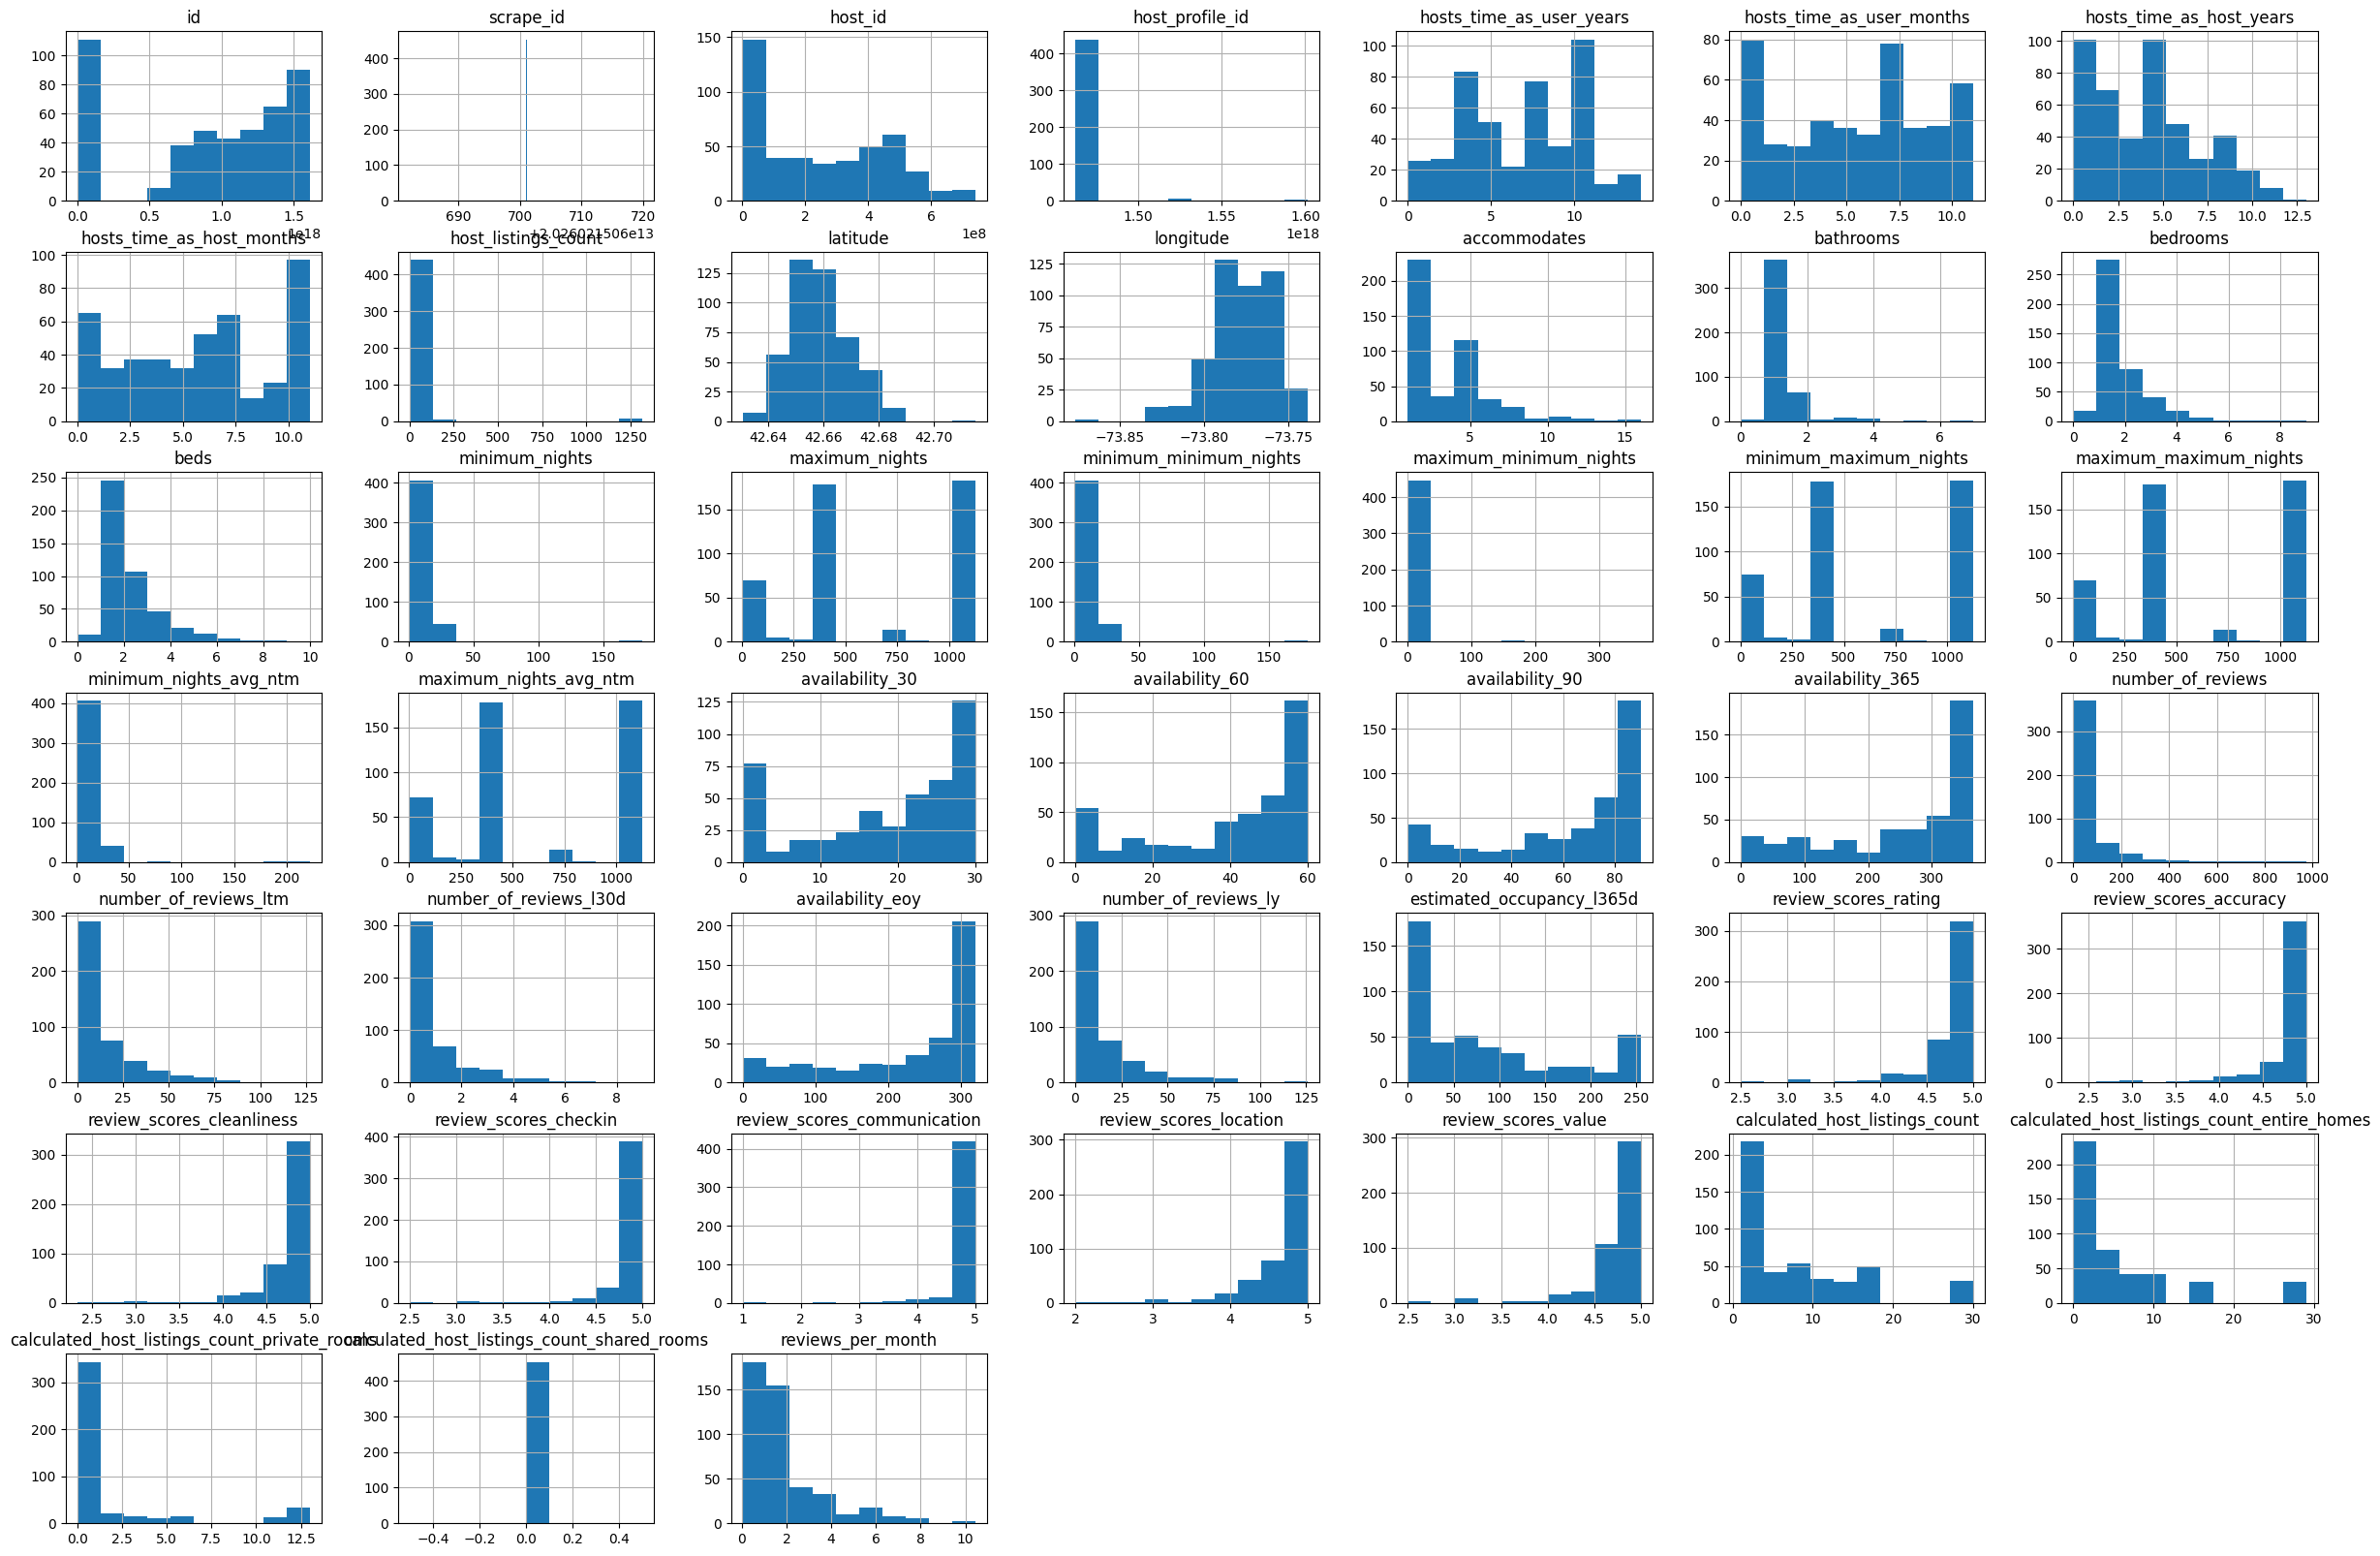

In [62]:
df.hist(figsize=(30,20))

# Correlation Heatmap

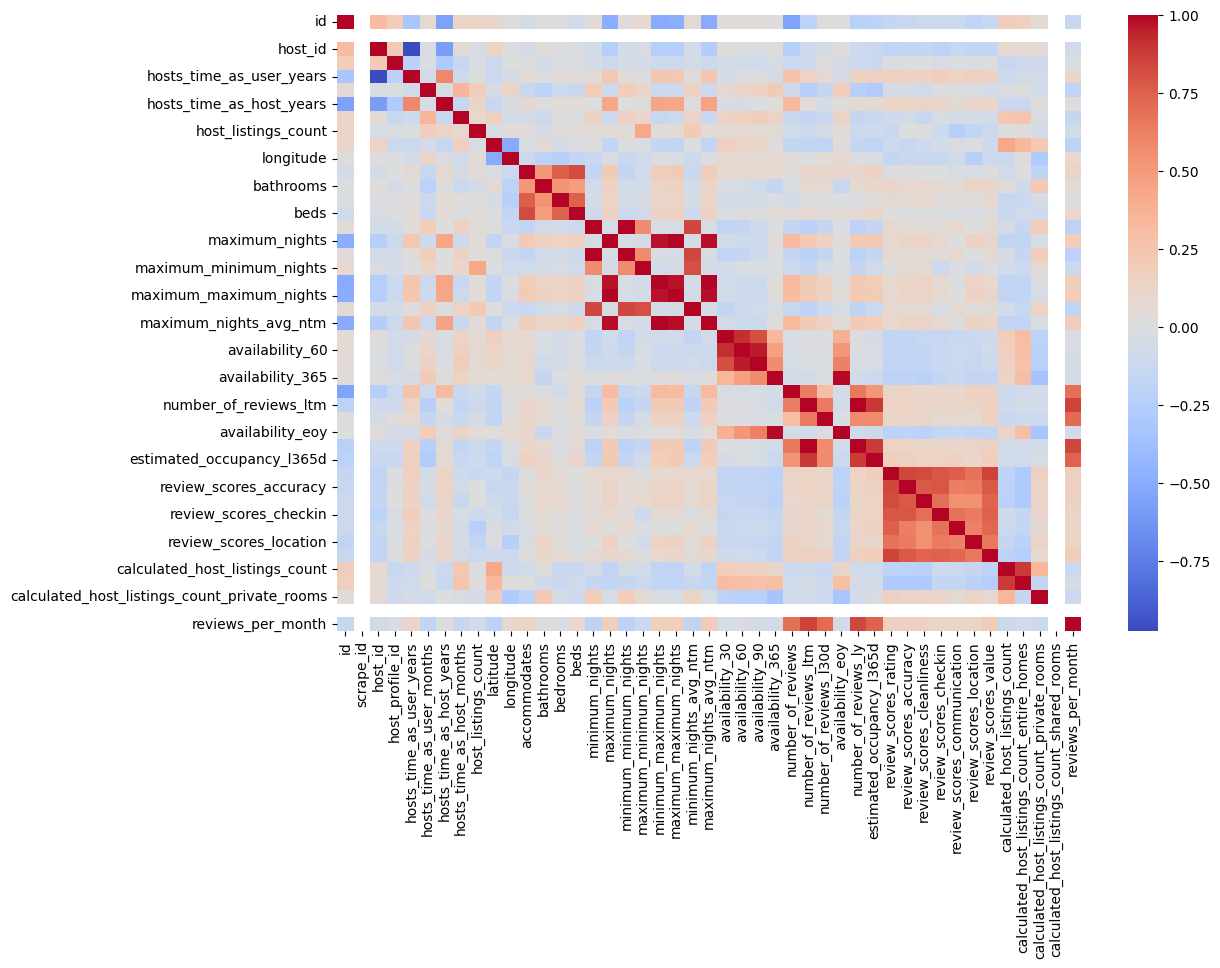

In [63]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

# Room Type Analysis

In [64]:
df.columns.tolist()

['id',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'host_id',
 'host_profile_id',
 'host_name',
 'hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_location',
 'host_about',
 'host_is_superhost',
 'host_picture_url',
 'host_listings_count',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'has_availability',
 'availability_30',
 'availability_60',
 'availability_90',
 'availability_365',
 'calendar_last_scraped',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'number_of_reviews_l30d',
 'availability_eoy',
 'number_of_re

In [65]:
df.columns[df.columns.str.contains('price', case=False)]

Index([], dtype='object')

ROOM TYPE ANALYSIS

In [66]:
df['room_type'].value_counts()

,count
room_type,
Entire home/apt,339
Private room,114


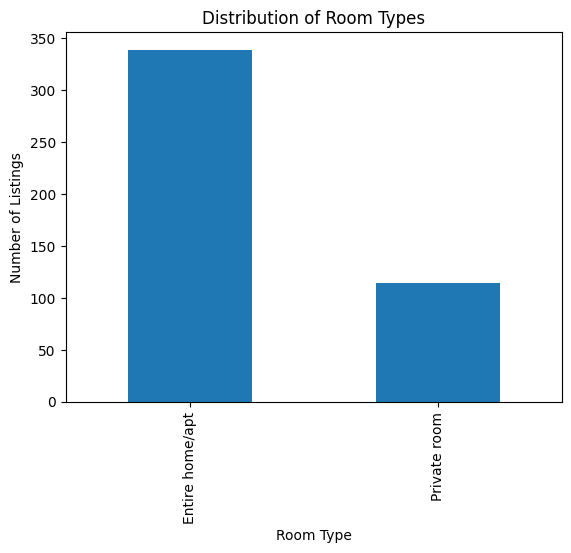

In [67]:
df['room_type'].value_counts().plot(kind='bar')
plt.title('Distribution of Room Types')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.show()

# Neighborhood Analysis

**Neighborhood Analysis**



Which neighborhoods have the most Airbnb listings?

In [68]:
df['neighbourhood_cleansed'].value_counts().head(10)

,count
neighbourhood_cleansed,
SIXTH WARD,106
TENTH WARD,49
SECOND WARD,43
THIRTEENTH WARD,39
NINTH WARD,36
THIRD WARD,33
ELEVENTH WARD,30
FOURTEENTH WARD,29
FIFTH WARD,19


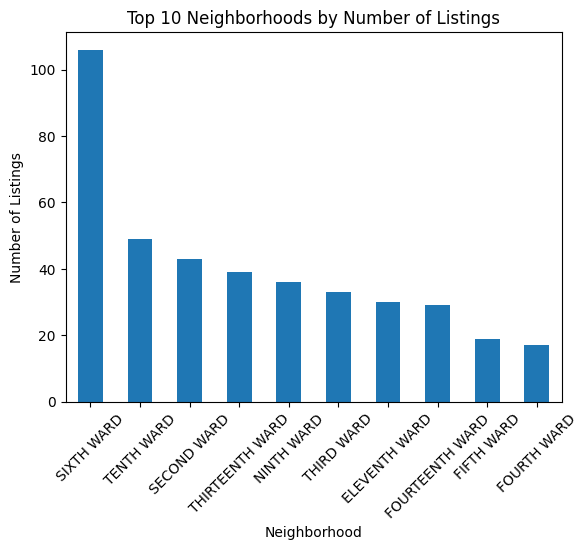

In [69]:

df['neighbourhood_cleansed'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Neighborhoods by Number of Listings')
plt.xlabel('Neighborhood')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.show()

MOST GUEST REVIEWS

In [70]:
df.groupby('neighbourhood_cleansed')['number_of_reviews'].sum().sort_values(ascending=False).head(10)

,number_of_reviews
neighbourhood_cleansed,
SIXTH WARD,8374
SECOND WARD,5246
FOURTEENTH WARD,3029
THIRTEENTH WARD,1803
NINTH WARD,1755
TENTH WARD,1384
FIFTEENTH WARD,1226
FOURTH WARD,965
THIRD WARD,957


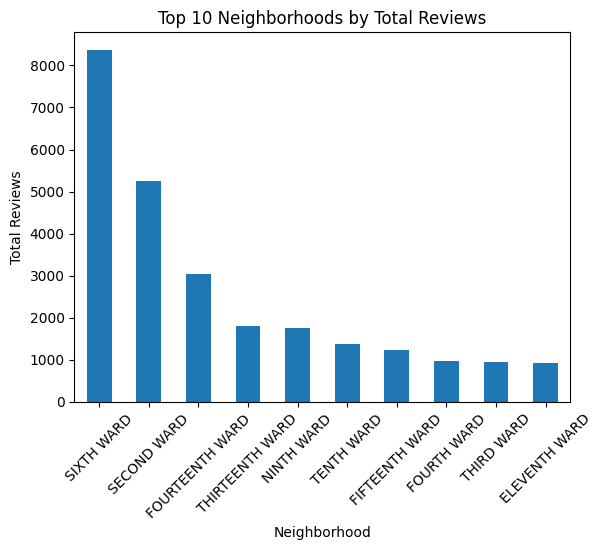

In [71]:
df.groupby('neighbourhood_cleansed')['number_of_reviews']\
  .sum()\
  .sort_values(ascending=False)\
  .head(10)\
  .plot(kind='bar')

plt.title('Top 10 Neighborhoods by Total Reviews')
plt.xlabel('Neighborhood')
plt.ylabel('Total Reviews')
plt.xticks(rotation=45)
plt.show()

# Host Type Analysis

DIFFERENECES BETWEEN SUPER HOST AND HOST

In [72]:
df.groupby('host_is_superhost')['number_of_reviews'].mean()

,number_of_reviews
host_is_superhost,
f,40.788382
t,85.198113


In [73]:
df['host_is_superhost'].value_counts()

,count
host_is_superhost,
f,241
t,212


# Review Rating Analysis

**REVIEW RATING ANALYSIS**

In [74]:
df[['review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value']].describe()

,review_scores_rating,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value
count,453.000000,453.000000,453.000000,453.000000,453.000000
mean,4.748234,4.765077,4.853002,4.653907,4.707837
std,0.359355,0.346731,0.342231,0.424887,0.378738
min,2.500000,2.330000,1.000000,2.000000,2.500000
25%,4.700000,4.710000,4.860000,4.560000,4.670000
50%,4.850000,4.870000,4.950000,4.790000,4.810000
75%,4.950000,4.960000,5.000000,4.910000,4.910000
max,5.000000,5.000000,5.000000,5.000000,5.000000


# Feature Correlation Analysis

CORRELATIONS

In [75]:
corr_cols = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating'
]

df[corr_cols].corr()

,accommodates,bathrooms,bedrooms,beds,availability_365,number_of_reviews,reviews_per_month,review_scores_rating
accommodates,1.000000,0.509536,0.753535,0.823553,0.096814,0.025855,0.131744,0.003566
bathrooms,0.509536,1.000000,0.531087,0.486032,-0.146472,-0.020428,0.051760,0.107801
bedrooms,0.753535,0.531087,1.000000,0.747471,-0.012004,-0.076588,-0.010666,0.069410
beds,0.823553,0.486032,0.747471,1.000000,0.054174,0.046352,0.091980,0.010319
availability_365,0.096814,-0.146472,-0.012004,0.054174,1.000000,-0.070713,-0.065521,-0.207822
number_of_reviews,0.025855,-0.020428,-0.076588,0.046352,-0.070713,1.000000,0.690617,0.123328
reviews_per_month,0.131744,0.051760,-0.010666,0.091980,-0.065521,0.690617,1.000000,0.165195
review_scores_rating,0.003566,0.107801,0.069410,0.010319,-0.207822,0.123328,0.165195,1.000000


# Export Cleaned Data for MySQL

CLEANED DATA

In [76]:
df.to_csv("cleaned_airbnb.csv", index=False)

# Database Connection Setup

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 65 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            453 non-null    int64  
 1   scrape_id                                     453 non-null    int64  
 2   last_scraped                                  453 non-null    object 
 3   source                                        453 non-null    object 
 4   name                                          453 non-null    object 
 5   description                                   453 non-null    object 
 6   host_id                                       453 non-null    int64  
 7   host_profile_id                               453 non-null    int64  
 8   host_name                                     453 non-null    object 
 9   hosts_time_as_user_years                      453 non-null    int

In [78]:
df.head(5)

,id,scrape_id,last_scraped,source,name,description,host_id,host_profile_id,host_name,hosts_time_as_user_years,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,20260215064701,2026-02-15,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,4621559,1462661762635155041,Kenneth,13,...,3.56,4.22,4.56,3.22,3.67,1,1,0,0,0.06
1,3820211,20260215064701,2026-02-15,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,19648678,1463087024016718788,Ming,11,...,4.87,4.85,4.81,4.82,4.78,7,7,0,0,2.26
2,5651579,20260215064701,2026-02-15,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",29288920,1465431505328745177,Gregg,10,...,4.45,4.81,4.86,4.76,4.63,2,1,1,0,2.96
3,6015313,20260215064701,2026-02-15,city scrape,Comfortable 3BR Home w/ Central Air | Pine Hills,Updated 3-bedroom home in Pine Hills near hosp...,31223807,1465459398999270556,Ryan,10,...,4.87,4.94,4.95,4.79,4.81,1,1,0,0,1.23
4,6623339,20260215064701,2026-02-15,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Step into the charming and comfy 1BR/1BA apart...,19648678,1463087024016718788,Ming,11,...,4.71,4.83,4.70,4.80,4.72,7,7,0,0,2.55


# Export for MySQL (UTF-8)

In [79]:
df.to_csv(
    "airbnb_mysql.csv",
    index=False,
    encoding="utf-8",
    lineterminator="\n"
)

In [80]:
!pip install pymysql sqlalchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.2 MB/s eta 0:00:00


# Final Data Check before DB Import

In [81]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "root"
password = quote_plus("Karthik@123")
host = "localhost"
port = "3306"
database = "customer_behavior"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 65 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            453 non-null    int64  
 1   scrape_id                                     453 non-null    int64  
 2   last_scraped                                  453 non-null    object 
 3   source                                        453 non-null    object 
 4   name                                          453 non-null    object 
 5   description                                   453 non-null    object 
 6   host_id                                       453 non-null    int64  
 7   host_profile_id                               453 non-null    int64  
 8   host_name                                     453 non-null    object 
 9   hosts_time_as_user_years                      453 non-null    int

# Display Head of DataFrame after Cleaning

In [83]:
df.head()

,id,scrape_id,last_scraped,source,name,description,host_id,host_profile_id,host_name,hosts_time_as_user_years,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,20260215064701,2026-02-15,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,4621559,1462661762635155041,Kenneth,13,...,3.56,4.22,4.56,3.22,3.67,1,1,0,0,0.06
1,3820211,20260215064701,2026-02-15,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,19648678,1463087024016718788,Ming,11,...,4.87,4.85,4.81,4.82,4.78,7,7,0,0,2.26
2,5651579,20260215064701,2026-02-15,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",29288920,1465431505328745177,Gregg,10,...,4.45,4.81,4.86,4.76,4.63,2,1,1,0,2.96
3,6015313,20260215064701,2026-02-15,city scrape,Comfortable 3BR Home w/ Central Air | Pine Hills,Updated 3-bedroom home in Pine Hills near hosp...,31223807,1465459398999270556,Ryan,10,...,4.87,4.94,4.95,4.79,4.81,1,1,0,0,1.23
4,6623339,20260215064701,2026-02-15,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Step into the charming and comfy 1BR/1BA apart...,19648678,1463087024016718788,Ming,11,...,4.71,4.83,4.70,4.80,4.72,7,7,0,0,2.55
